## 1. Import

In [1]:
import torch
from torch_geometric.datasets import QM9
from torch_geometric.utils import to_networkx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 2. Dataset

In [2]:
dataset = QM9(root="../data/qm9")

print(f"Numero di molecole: {len(dataset)}")
print(f"Prima molecola: {dataset[0]}")
print(f"Numero di atomi (prima molecola): {dataset[0].x.shape[0]}")
print(f"Features per atomo: {dataset[0].x.shape[1]}")
print(f"Numero di proprietà target: {dataset[0].y.shape[1]}")

Extracting ../data/qm9/raw/qm9.zip
Processing...
100%|██████████| 133885/133885 [01:39<00:00, 1339.67it/s]
Done!


Numero di molecole: 130831
Prima molecola: Data(x=[5, 11], edge_index=[2, 8], edge_attr=[8, 4], y=[1, 19], pos=[5, 3], z=[5], smiles='[H]C([H])([H])[H]', name='gdb_1', idx=[1])
Numero di atomi (prima molecola): 5
Features per atomo: 11
Numero di proprietà target: 19


## 3. Target properties name

In [4]:
# Le 19 proprietà di QM9 (unità SI)
target_names = [
    'mu (D)', 'alpha (a0^3)', 'homo (eV)', 'lumo (eV)', 'gap (eV)',
    'r2 (a0^2)', 'zpve (eV)', 'u0 (eV)', 'u298 (eV)', 'h298 (eV)',
    'g298 (eV)', 'cv (cal/mol/K)', 'u0_atom (eV)', 'u298_atom (eV)',
    'h298_atom (eV)', 'g298_atom (eV)', 'a (GHz)', 'b (GHz)', 'c (GHz)'
]

print("Predicted properties by the dataset QM9:")
for i, name in enumerate(target_names):
    print(f"  [{i:2d}] {name}")

Predicted properties by the dataset QM9:
  [ 0] mu (D)
  [ 1] alpha (a0^3)
  [ 2] homo (eV)
  [ 3] lumo (eV)
  [ 4] gap (eV)
  [ 5] r2 (a0^2)
  [ 6] zpve (eV)
  [ 7] u0 (eV)
  [ 8] u298 (eV)
  [ 9] h298 (eV)
  [10] g298 (eV)
  [11] cv (cal/mol/K)
  [12] u0_atom (eV)
  [13] u298_atom (eV)
  [14] h298_atom (eV)
  [15] g298_atom (eV)
  [16] a (GHz)
  [17] b (GHz)
  [18] c (GHz)


## 4. Build a dataframe with molecular properties

In [5]:
targets = torch.stack([data.y for data in dataset]).squeeze()
df = pd.DataFrame(targets.numpy(), columns=target_names)

print(df.describe().round(3))

           mu (D)  alpha (a0^3)   homo (eV)   lumo (eV)    gap (eV)  \
count  130831.000    130831.000  130831.000  130831.000  130831.000   
mean        2.673        75.281      -6.536       0.322       6.858   
std         1.503         8.174       0.598       1.275       1.284   
min         0.000         6.310     -11.663      -4.762       0.669   
25%         1.578        70.480      -6.874      -0.634       5.905   
50%         2.475        75.600      -6.561       0.343       6.808   
75%         3.596        80.610      -6.229       1.385       7.875   
max        29.556       196.620      -2.767       5.265      16.928   

        r2 (a0^2)   zpve (eV)     u0 (eV)   u298 (eV)   h298 (eV)   g298 (eV)  \
count  130831.000  130831.000  130831.000  130831.000  130831.000  130831.000   
mean     1189.411       4.057  -11178.966  -11178.736  -11178.709  -11179.876   
std       280.478       0.902    1085.579    1085.573    1085.573    1085.592   
min        19.000       0.434  -1944

## 5. Distribution of key properties

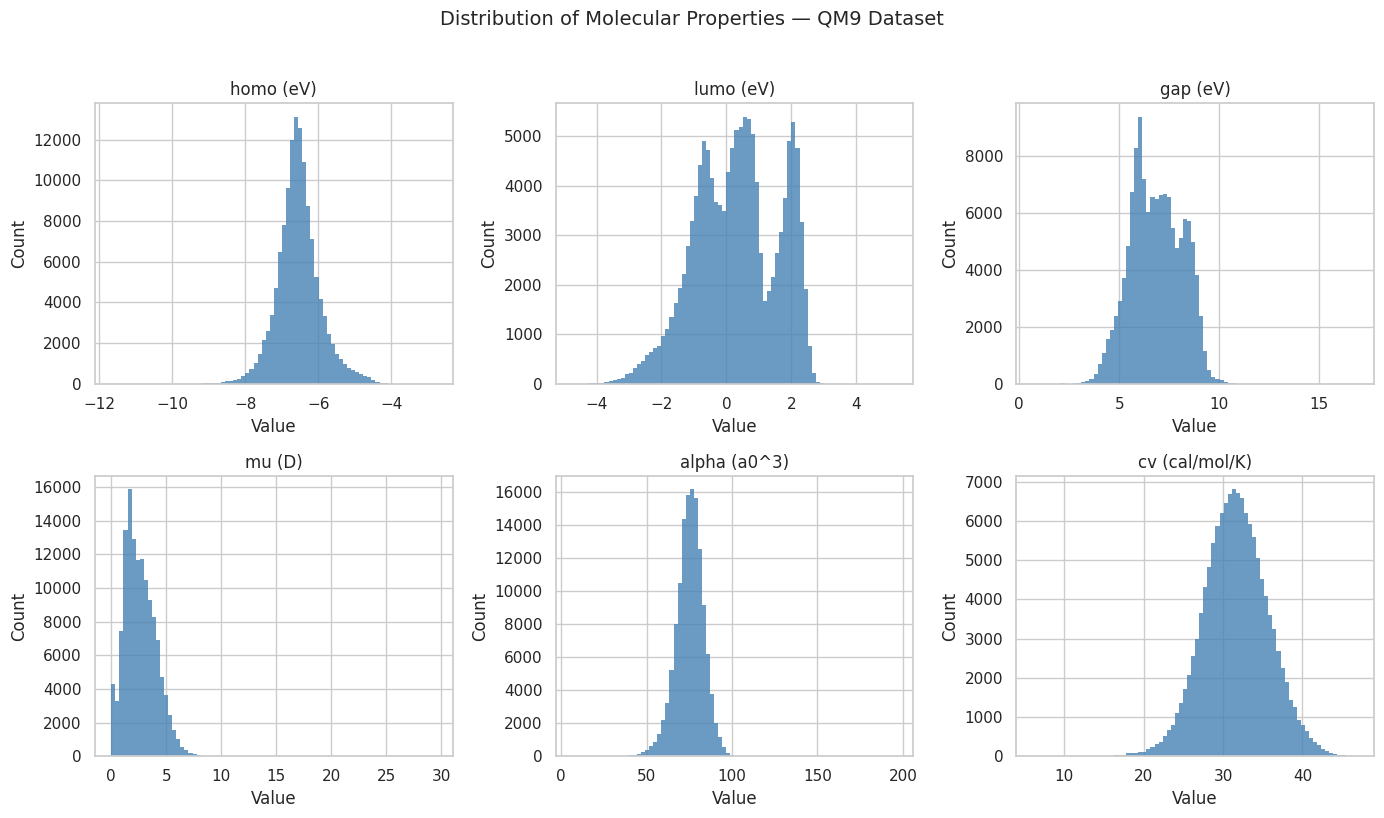

Plot saved ✓


In [6]:
props_to_plot = ['homo (eV)', 'lumo (eV)', 'gap (eV)', 'mu (D)', 'alpha (a0^3)', 'cv (cal/mol/K)']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, prop in enumerate(props_to_plot):
    axes[i].hist(df[prop], bins=80, color='steelblue', edgecolor='none', alpha=0.8)
    axes[i].set_title(prop, fontsize=12)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")

plt.suptitle("Distribution of Molecular Properties — QM9 Dataset", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../data/eda_distributions.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved ✓")

## 6. Correlation heatmaps

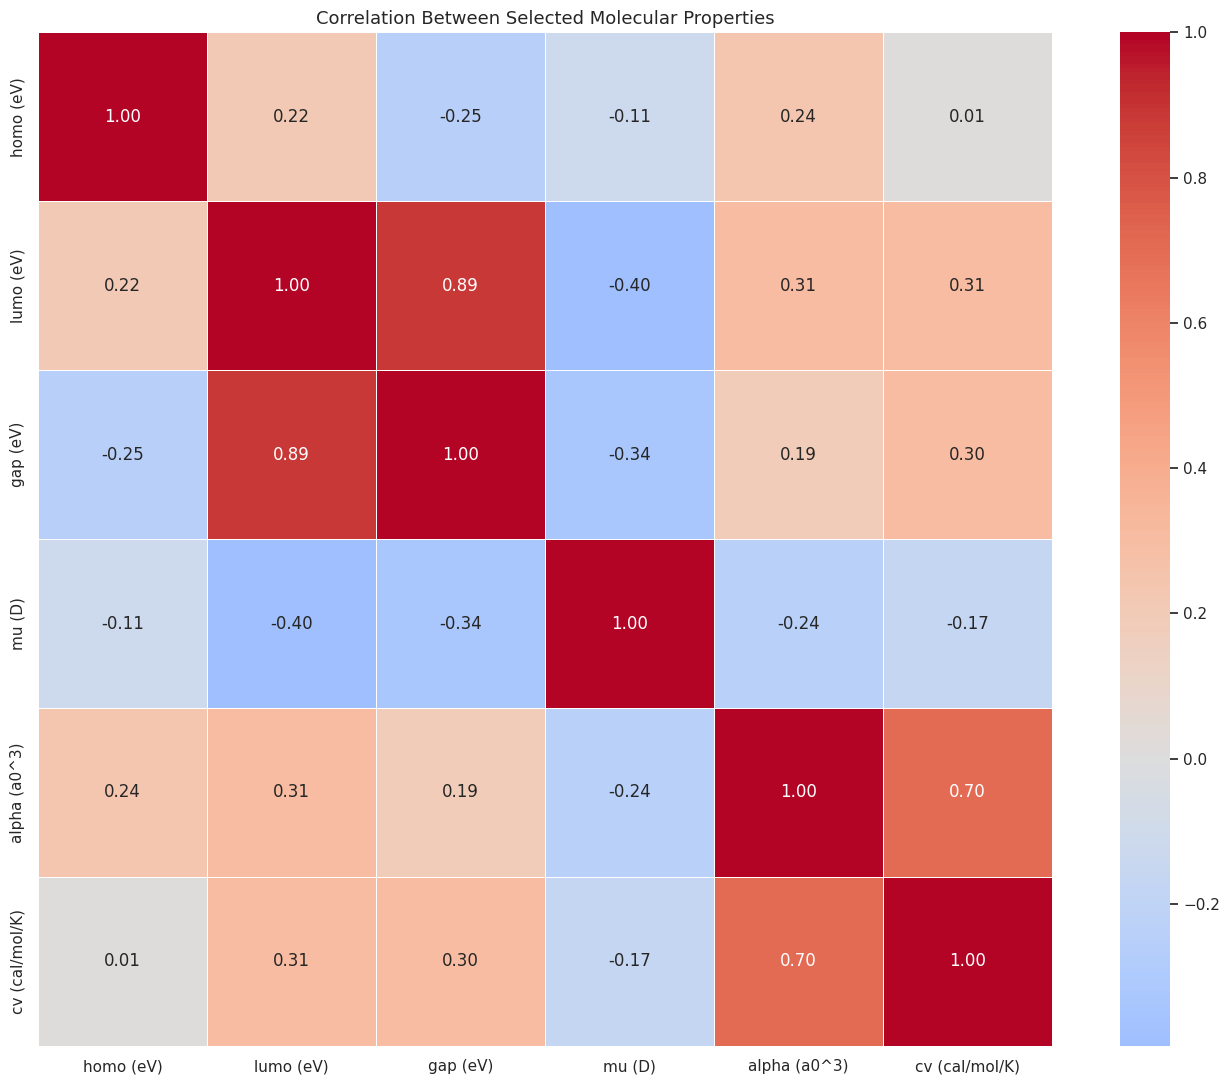

Heatmap saved ✓


In [7]:
fig, ax = plt.subplots(figsize=(14, 11))

corr = df[props_to_plot].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, square=True, linewidths=0.5)

ax.set_title("Correlation Between Selected Molecular Properties", fontsize=13)
plt.tight_layout()
plt.savefig("../data/eda_correlation.png", dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap saved ✓")

## Key Observations

- The **HOMO** energy distribution is approximately normal, centered around -6.5 eV
- The **LUMO** energy shows a multimodal distribution, suggesting distinct structural subgroups in the dataset
- **LUMO and gap** are highly correlated (r=0.89), consistent with the physical definition of the HOMO-LUMO gap
- **Alpha and Cv** show strong correlation (r=0.70), both being size-dependent molecular properties
- **Mu (dipole moment)** is largely independent of electronic gap properties, as expected

These observations guide our modeling choices: we will predict **gap (eV)** as the primary target,
given its physical relevance and well-behaved distribution.